# TCREmp feature comparison: V+J+CDR3 vs CDR1+CDR2+CDR3

`mir.embedding.tcremp.TCREmp` supports two embedding modes:

* **`vjcdr3`** (default) — V-gene, J-gene and CDR3/junction distances.
* **`cdr123`** — CDR1, CDR2 (germline V-gene-determined, precomputed from the
  library's arda-derived region annotations) and CDR3/junction distances.

This notebook embeds the same balanced VDJdb TRB set with **both** modes and
compares antigen-specificity structure via PCA -> L2 -> kneedle DBSCAN and UMAP.
It mirrors `tcremp_vdjdb_analysis.ipynb` but varies the feature set instead of
the junction backend.

In [1]:
import importlib.metadata as _meta, sys as _sys
print(f"Python {_sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "numpy", "pandas", "scikit-learn", "umap-learn", "kneed"]:
    try: print(f"  {_pkg}: {_meta.version(_pkg)}")
    except _meta.PackageNotFoundError: pass

import os, sys, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler, normalize as l2normalize
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import umap
from kneed import KneeLocator

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path: sys.path.insert(0, str(repo_root))

from mir.common.clonotype import Clonotype
from mir.embedding.tcremp import TCREmp
from mir.utils.notebook_assets import ensure_airr_benchmark, find_airr_benchmark_vdjdb_slim

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"font.family": "sans-serif", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 120})

FOCAL_EPITOPES = ["CIN","ELA","GIL","GLC","LLW","NLV","PKY","SPR","TFE","TTD","YLQ"]
_COLORS_11 = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00","#a65628",
              "#f781bf","#17becf","#e7298a","#1b9e77","#d95f02"]
EPITOPE_PALETTE = dict(zip(FOCAL_EPITOPES, _COLORS_11)); EPITOPE_PALETTE["other"] = "#cccccc"

Python 3.12.12
  mirpy-lib: 1.1.1
  numpy: 1.26.4
  pandas: 2.2.1
  scikit-learn: 1.3.0
  umap-learn: 0.5.3
  kneed: 0.8.5


/opt/homebrew/anaconda3/lib/python3.12/site-packages/umap/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Load VDJdb slim and build a balanced human TRB subset (non-10x).
benchmark_root = ensure_airr_benchmark(repo_root, allow_patterns=["vdjdb/**"])
vdjdb = pd.read_csv(find_airr_benchmark_vdjdb_slim(benchmark_root), sep="\t")

df = vdjdb[~vdjdb["reference.id"].astype(str).str.contains("10[xX]", na=False)]
df = df[df["species"].astype(str).str.lower().isin(["homosapiens", "human"])]
df = df[df["gene"] == "TRB"].copy()
for col in ["cdr3", "v.segm", "j.segm", "antigen.epitope"]:
    df[col] = df[col].astype(str).str.strip()
df = df[df["cdr3"].str.len().between(5, 29) & (df["v.segm"].str.len() > 0)
        & (df["j.segm"].str.len() > 0) & (~df["antigen.epitope"].isin(["nan", ""]))]
df = df.drop_duplicates(subset=["cdr3", "v.segm", "j.segm", "antigen.epitope"])

# Map focal short codes to full epitope sequences (data-driven, by prefix).
FOCAL_MAP = {}
for pfx in FOCAL_EPITOPES:
    hits = df[df["antigen.epitope"].str.startswith(pfx, na=False)]["antigen.epitope"].value_counts()
    if len(hits): FOCAL_MAP[pfx] = hits.index[0]
SEQ2CODE = {v: k for k, v in FOCAL_MAP.items()}
df["epitope_cat"] = df["antigen.epitope"].map(SEQ2CODE)
# Benchmark on labelled focal epitopes only: the question is how well each
# feature set separates known specificities, so the heterogeneous non-focal
# pool (which fragments clusters) is excluded.
df = df[df["epitope_cat"].notna()].copy()

# Balance: cap sequences per focal epitope.
rng = np.random.RandomState(SEED)
keep = []
for cat, grp in df.groupby("epitope_cat"):
    idx = grp.index.to_numpy()
    keep.extend(rng.choice(idx, size=min(len(idx), 500), replace=False).tolist())
df_trb = df.loc[keep].reset_index(drop=True)
print(f"Balanced TRB (focal epitopes only): {len(df_trb):,} clonotypes")
print(df_trb["epitope_cat"].value_counts().to_string())

Balanced TRB (focal epitopes only): 5,025 clonotypes
epitope_cat
ELA    500
GIL    500
GLC    500
NLV    500
SPR    500
YLQ    500
TFE    445
TTD    438
LLW    409
PKY    372
CIN    361


In [3]:
# Build clonotypes and labels.
clonos = [Clonotype(sequence_id=str(i), locus="TRB", v_gene=r["v.segm"],
                    j_gene=r["j.segm"], junction_aa=r["cdr3"],
                    duplicate_count=1, _validate=False)
          for i, r in df_trb.iterrows()]
labels = df_trb["epitope_cat"].to_numpy()
print(f"{len(clonos):,} TRB clonotypes; labels: {sorted(set(labels))}")

5,025 TRB clonotypes; labels: ['CIN', 'ELA', 'GIL', 'GLC', 'LLW', 'NLV', 'PKY', 'SPR', 'TFE', 'TTD', 'YLQ']


In [4]:
# Embed with both feature modes (1000 prototypes each).
N_PROTO = 1000
MODES = ["vjcdr3", "cdr123"]
embeddings = {}
for mode in MODES:
    model = TCREmp.from_defaults(species="human", locus="TRB",
                                 n_prototypes=N_PROTO, mode=mode)
    t0 = time.perf_counter()
    X = model.embed(clonos, n_jobs=None)
    print(f"{mode}: {X.shape} in {time.perf_counter()-t0:.1f}s")
    embeddings[mode] = X

vjcdr3: (5025, 3000) in 0.2s
cdr123: (5025, 3000) in 0.2s


In [5]:
# Shared pipeline: scale -> PCA(90%) -> L2 -> kneedle eps -> DBSCAN.
def run_pipeline(X, k=4, min_samples=3, variance=0.90):
    Xs = StandardScaler().fit_transform(X)
    cum = np.cumsum(PCA(random_state=SEED).fit(Xs).explained_variance_ratio_)
    n = int(np.searchsorted(cum, variance)) + 1
    coords = l2normalize(PCA(n_components=n, random_state=SEED).fit_transform(Xs))
    nn = NearestNeighbors(n_neighbors=k).fit(coords)
    kth = np.sort(nn.kneighbors(coords)[0][:, -1])
    kl = KneeLocator(np.arange(len(kth)), kth, curve="convex",
                     direction="increasing", interp_method="polynomial")
    eps = float(kth[kl.knee]) if kl.knee is not None else float(np.percentile(kth, 10))
    clusters = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit_predict(coords)
    return dict(coords=coords, n_pcs=n, eps=eps, clusters=clusters)

def metrics(labels, clusters, threshold=0.70):
    mask = clusters != -1
    retention = float(mask.sum()) / len(clusters)
    purs = []
    for cid in np.unique(clusters[mask]):
        cl = labels[clusters == cid]
        purs.append(pd.Series(cl).value_counts().iloc[0] / len(cl))
    return dict(n_clusters=len(purs), retention=retention,
                purity=float(np.mean(purs)),
                consistency=float(np.mean([p >= threshold for p in purs])))

results = {m: run_pipeline(embeddings[m]) for m in MODES}
summary = pd.DataFrame(
    [{"mode": m, "n_pcs": results[m]["n_pcs"], "eps": round(results[m]["eps"], 4),
      **metrics(labels, results[m]["clusters"])} for m in MODES]
).set_index("mode")
print(summary.to_string())

        n_pcs     eps  n_clusters  retention    purity  consistency
mode                                                               
vjcdr3     27  0.4072          95   0.946468  0.355602     0.042105
cdr123     24  0.4326          35   0.947861  0.465197     0.114286


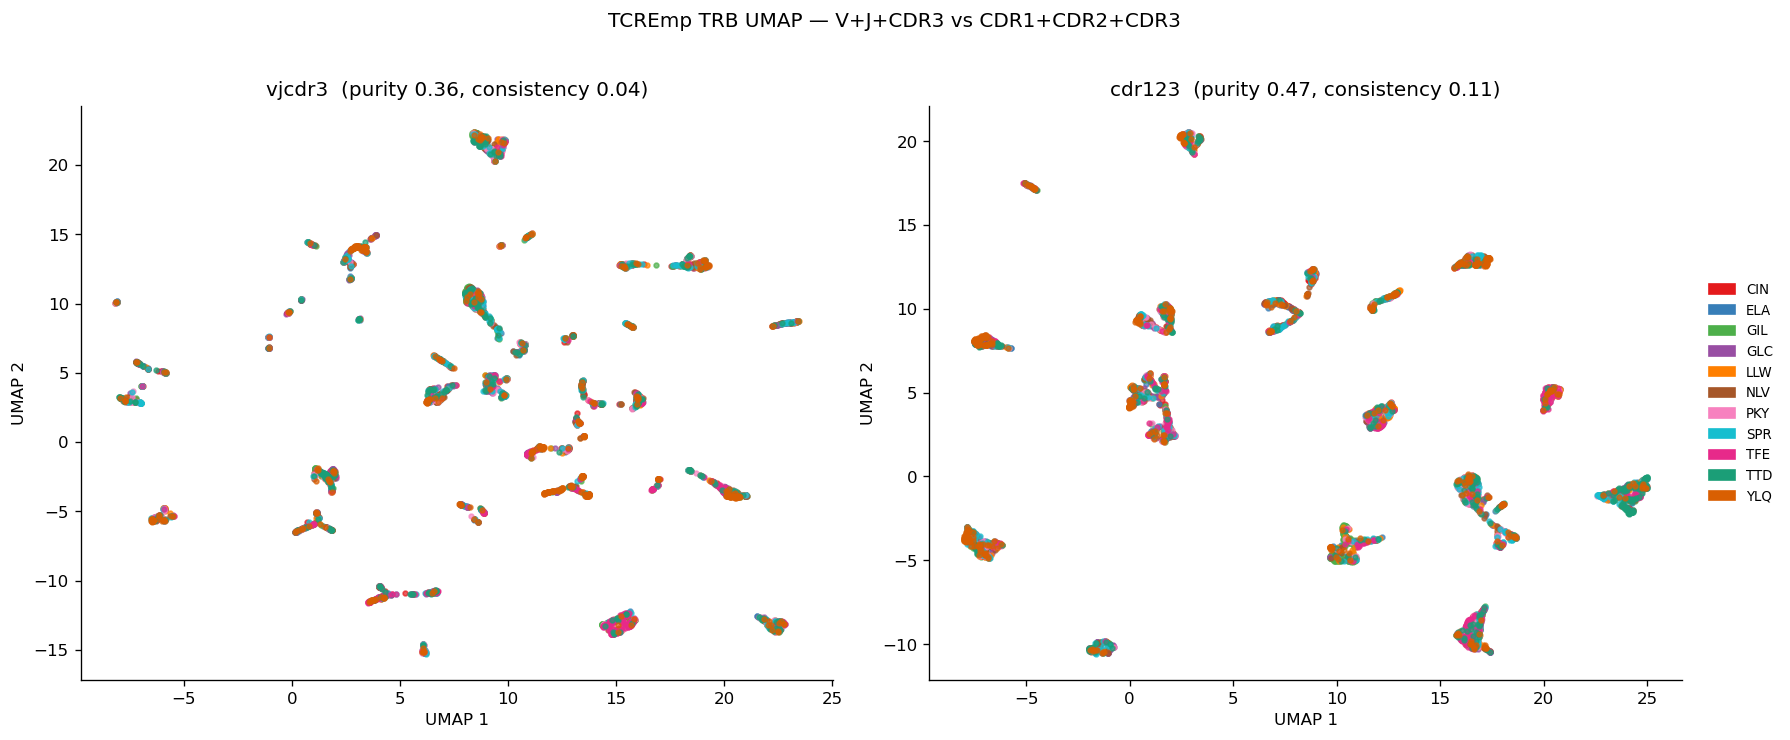

In [6]:
# UMAP for each mode, coloured by epitope.
UMAP_PARAMS = dict(n_components=2, n_neighbors=30, min_dist=0.1,
                   metric="euclidean", random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, mode in zip(axes, MODES):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        xy = umap.UMAP(**UMAP_PARAMS).fit_transform(results[mode]["coords"])
    other = labels == "other"
    ax.scatter(xy[other, 0], xy[other, 1], c=EPITOPE_PALETTE["other"],
               s=6, alpha=0.25, rasterized=True)
    for ep in FOCAL_EPITOPES:
        m = labels == ep
        if m.sum(): ax.scatter(xy[m, 0], xy[m, 1], c=EPITOPE_PALETTE[ep],
                               s=8, alpha=0.7, rasterized=True, label=ep)
    md_ = metrics(labels, results[mode]["clusters"])
    ax.set_title(f"{mode}  (purity {md_['purity']:.2f}, "
                 f"consistency {md_['consistency']:.2f})")
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
handles = [mpatches.Patch(color=EPITOPE_PALETTE[ep], label=ep) for ep in FOCAL_EPITOPES]
axes[1].legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
               frameon=False, fontsize=8)
plt.suptitle("TCREmp TRB UMAP — V+J+CDR3 vs CDR1+CDR2+CDR3", y=1.02)
plt.tight_layout(); plt.show()

## Summary

Both feature sets embed the same balanced VDJdb TRB set into a 3000-dim distance
space (1000 prototypes); only the per-prototype triple differs — `vjcdr3` uses
`[V, J, CDR3]` while `cdr123` uses `[CDR1, CDR2, CDR3]`. The table and UMAP panels
above contrast their antigen-specificity structure (retention / purity /
consistency from kneedle-DBSCAN on L2-normalised PCA coordinates).

Because CDR1/CDR2 are germline V-gene-determined, `cdr123` re-weights the
embedding toward germline contact loops rather than V/J identity; CDR3 is shared
by both. Use this comparison to choose the feature set for a downstream task.